In [1]:
import pandas as pd
import numpy as np

## Loading Raw Data

In [2]:
raw_train = pd.read_csv(
    "train.csv",
    dtype={"StateHoliday": str},
    low_memory=False
)

raw_store = pd.read_csv('store.csv')

## Creating a copy of a raw data

In [3]:
train = raw_train.copy()
store = raw_store.copy()

In [4]:
train.shape, store.shape

((1017209, 9), (1115, 10))

In [5]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [7]:
rossmann = train.merge(store, on='Store', how='left')

In [8]:
rossmann.shape

(1017209, 18)

In [9]:
rossmann.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


# Data Cleaning 

## Giving appropriate Datatype 

In [10]:
rossmann['Date'] = pd.to_datetime(rossmann['Date'])

In [11]:
rossmann = rossmann.astype({
        "Store": "int16",
        "DayOfWeek": "int8",
        "Sales": "int32",
        "Customers": "int16",
        "Open": "int8",
        "Promo": "int8",
        "SchoolHoliday": "int8",
        "Promo2": "int8",
    })

## Replacing missing values with approproiate values

In [12]:
rossmann['CompetitionDistance'] = rossmann['CompetitionDistance'].fillna(rossmann['CompetitionDistance'].median())

# Distance in in metres

In [13]:
rossmann['CompetitionOpenSinceMonth'] = rossmann['CompetitionOpenSinceMonth'].fillna(0)
rossmann['CompetitionOpenSinceYear'] = rossmann['CompetitionOpenSinceYear'].fillna(0)

In [14]:
rossmann['Promo2SinceWeek'] = rossmann['Promo2SinceWeek'].fillna(0)
rossmann['Promo2SinceYear'] = rossmann['Promo2SinceYear'].fillna(0)

In [15]:
rossmann['PromoInterval'] = rossmann['PromoInterval'].fillna('None')

In [16]:
rossmann.shape

(1017209, 18)

### Checking Duplicate values

In [17]:
rossmann.duplicated().sum()

np.int64(0)

### Removing rows when Store was Closed and Sales were 0

In [18]:
rossmann[rossmann['Open'] == 0]['Sales'].sum()

np.int64(0)

In [19]:
rossmann = rossmann[rossmann['Open'] == 1]

In [20]:
rossmann = rossmann[rossmann['Sales'] > 0]

### Handling Categorical Variables

In [21]:
rossmann.select_dtypes(include='object').columns

Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object')

In [22]:
rossmann['StateHoliday'] = rossmann['StateHoliday'].astype(str)

In [ ]:
rossmann.to_csv('Rossmann_cleaned.csv', index = False)

# Feature Engineering

### Extracting Date Features

In [28]:
rossmann['Year'] = rossmann['Date'].dt.year
rossmann['Month'] = rossmann['Date'].dt.month
rossmann['Day'] = rossmann['Date'].dt.day
rossmann['WeekOfYear'] = rossmann['Date'].dt.isocalendar().week
rossmann['Quarter'] = rossmann['Date'].dt.quarter
rossmann['DayOfWeek'] = rossmann['Date'].dt.dayofweek

### Weekend Feature, Month Start/End Features and Competition Feature

In [29]:
rossmann['IsWeekend'] = rossmann['DayOfWeek'].isin([5, 6]).astype(int)

In [30]:
rossmann['IsMonthStart'] = rossmann['Date'].dt.is_month_start.astype(int)
rossmann['IsMonthEnd'] = rossmann['Date'].dt.is_month_end.astype(int)

In [31]:
rossmann['CompetitionOpenSince'] = (
    (rossmann['Year'] - rossmann['CompetitionOpenSinceYear']) * 12 +
    (rossmann['Month'] - rossmann['CompetitionOpenSinceMonth'])
)

# Values in months

In [32]:
rossmann['CompetitionOpenSince'] = rossmann['CompetitionOpenSince'].clip(lower=0)

### Promo Features

In [41]:
rossmann['PromoOpenSince'] = 0

mask = rossmann['Promo2'] == 1

rossmann.loc[mask, 'PromoOpenSince'] = (
    (rossmann.loc[mask, 'Year'] - rossmann.loc[mask, 'Promo2SinceYear']) * 12 +
    (rossmann.loc[mask, 'WeekOfYear'] - rossmann.loc[mask, 'Promo2SinceWeek']) / 4
)

rossmann['PromoOpenSince'] = rossmann['PromoOpenSince'].clip(lower=0)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15040\3295778069.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<FloatingArray>
[ 64.5, 52.25,  43.5,  64.5,  68.5, 45.75, 52.25, 61.25, 40.25, 50.25,
 ...
  -7.5,  33.0,  6.75,  -7.5,  6.75, -2.25,  -7.5, -3.25,  -1.0,  0.25]
Length: 421046, dtype: Float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rossmann.loc[mask, 'PromoOpenSince'] = (


In [51]:
month_map = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

rossmann['MonthStr'] = rossmann['Month'].map(month_map)

rossmann['IsPromoMonth'] = 0

rossmann['IsPromoMonth'] = rossmann.apply(
    lambda x: 1 if isinstance(x['PromoInterval'], str)
    and x['MonthStr'] in x['PromoInterval']
    else 0,
    axis=1
)

### Customer Feature

In [61]:
rossmann['SalesPerCustomer'] = rossmann['Sales'] / rossmann['Customers']

### Store Feature

In [66]:
store_avg_sales = rossmann.groupby('Store')['Sales'].mean()

rossmann['AvgStoreSales'] = rossmann['Store'].map(store_avg_sales)

In [71]:
store_avg_customers = rossmann.groupby('Store')['Customers'].mean()

rossmann['AvgStoreCustomers'] = rossmann['Store'].map(store_avg_customers)

In [3]:
rossmann = pd.read_csv('Rossmann_CleanedwithFeatures')

C:\Users\Admin\AppData\Local\Temp\ipykernel_15596\1998307377.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  rossmann = pd.read_csv('Rossmann_CleanedwithFeatures')


In [4]:
rossmann.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,IsWeekend,IsMonthStart,IsMonthEnd,CompetitionOpenSince,PromoOpenSince,MonthStr,IsPromoMonth,SalesPerCustomer,AvgStoreSales,AvgStoreCustomers
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,0,0,1,82.0,0.00,Jul,0,9.482883,4759.096031,564.049936
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,0,0,1,92.0,64.50,Jul,1,9.702400,4953.900510,583.998724
2,3,4,2015-07-31,8314,821,1,1,0,1,a,...,0,0,1,103.0,52.25,Jul,1,10.126675,6942.568678,750.077022
3,4,4,2015-07-31,13995,1498,1,1,0,1,c,...,0,0,1,70.0,0.00,Jul,0,9.342457,9638.401786,1321.752551
4,5,4,2015-07-31,4822,559,1,1,0,1,a,...,0,0,1,3.0,0.00,Jul,0,8.626118,4676.274711,537.340180


In [7]:
rossmann['StateHoliday'] = rossmann['StateHoliday'].astype(str)

In [14]:
rossmann['StateHoliday'].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

In [10]:
rossmann.to_csv('Rossmann_CleanedwithFeatures.csv', index = False)

### LAG Features

In [5]:
rossmann2 = rossmann.copy()

In [6]:
rossmann2 = rossmann2.sort_values(['Store', 'Date'])

rossmann2['LagSales1'] = rossmann2.groupby('Store')['Sales'].shift(1)
rossmann2['LagSales7'] = rossmann2.groupby('Store')['Sales'].shift(7)

#### Rolling Averages

In [14]:
rossmann2['RollingMean7'] = (
    rossmann2.groupby('Store')['Sales']
    .shift(1)
    .rolling(7)
    .mean()
)

rossmann2['RollingMean30'] = (
    rossmann2.groupby('Store')['Sales']
    .shift(1)
    .rolling(30)
    .mean()
)

# Interquartile Range Method

q1 = rossmann['Sales'].quantile(0.25)
q3 = rossmann['Sales'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
 
To identify outliers

### One Hot Encoding variables with category

In [18]:
rossmann2 = pd.get_dummies(
    rossmann2,
    columns=['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval'],
    drop_first=True
)

In [19]:
rossmann2.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,StoreType_2,StoreType_3,Assortment_1,Assortment_2,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,"PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
843210,1,2,2013-01-02,5530,668,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
842101,1,3,2013-01-03,4327,578,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
840993,1,4,2013-01-04,4486,619,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
839886,1,5,2013-01-05,4997,635,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
838761,1,0,2013-01-07,7176,785,1,1,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False


In [21]:
rossmann2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 843210 to 1112
Data columns (total 44 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Store                           844338 non-null  int64  
 1   DayOfWeek                       844338 non-null  int64  
 2   Date                            844338 non-null  object 
 3   Sales                           844338 non-null  int64  
 4   Customers                       844338 non-null  int64  
 5   Open                            844338 non-null  int64  
 6   Promo                           844338 non-null  int64  
 7   SchoolHoliday                   844338 non-null  int64  
 8   CompetitionDistance             844338 non-null  float64
 9   CompetitionOpenSinceMonth       844338 non-null  float64
 10  CompetitionOpenSinceYear        844338 non-null  float64
 11  Promo2                          844338 non-null  int64  
 12  Promo2SinceWeek   

In [28]:
rossmann2.shape

(844338, 44)

### Log transform Target Variable

In [29]:
rossmann2['Sales'] = np.log1p(rossmann2['Sales'])

In [30]:
rossmann2.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,StoreType_2,StoreType_3,Assortment_1,Assortment_2,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,"PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
843210,1,2,2013-01-02,8.618124,668,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
842101,1,3,2013-01-03,8.372861,578,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
840993,1,4,2013-01-04,8.408940,619,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
839886,1,5,2013-01-05,8.516793,635,1,0,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False
838761,1,0,2013-01-07,8.878637,785,1,1,1,1270.0,9.0,...,True,False,False,False,True,False,False,False,False,False


In [ ]:
rossmann2.to_csv('Rossmann_withMLfeatures.csv', index = False)

In [2]:
rossmann2 = pd.read_csv('Rossmann_withMLfeatures.csv')

In [3]:
rossmann2.shape

(844338, 44)

# STATISTICS

### Hypothesis

<Axes: xlabel='Sales', ylabel='Count'>

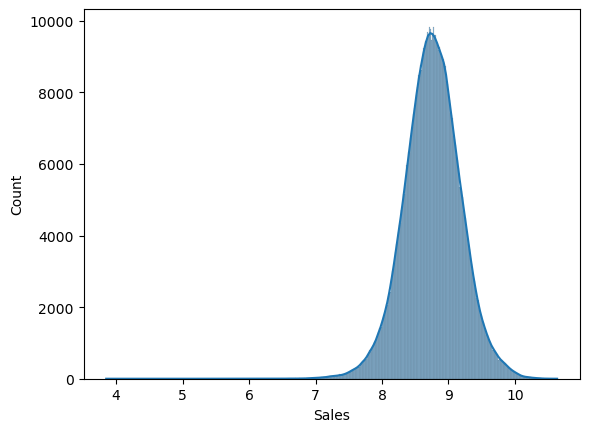

In [5]:
import seaborn as sns
sns.histplot(rossmann2['Sales'], kde=True)

In [7]:
rossmann2['Sales'].skew()

np.float64(-0.10932694615874194)

In [8]:
rossmann2[['Sales', 'Customers', 'Promo']].corr()

,Sales,Customers,Promo
Sales,1.000000,0.756676,0.404686
Customers,0.756676,1.000000,0.182859
Promo,0.404686,0.182859,1.000000


### T-Test

In [5]:
promo_sales = rossmann2[rossmann2['Promo'] == 1]['Sales']

nonpromo_sales = rossmann2[rossmann2['Promo'] == 0]['Sales']

In [11]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(promo_sales, nonpromo_sales)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 406.64333101597214
P-value: 0.0


### -Statistical testing confirms promotions significantly increase store sales.

### CHI-SQUARE Test

In [3]:
rossmann = pd.read_csv("D:\Rossmann Sales Forecasting Project\Rossmann_cleaned.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_15176\938556186.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  rossmann = pd.read_csv("D:\Rossmann Sales Forecasting Project\Rossmann_cleaned.csv")


In [17]:
pd.crosstab(rossmann['StoreType'], rossmann['Promo'])



Promo,0,1
StoreType,,
a,252532,204510
b,9622,5938
c,62235,50733
d,143074,115694


In [18]:
from scipy.stats import chi2_contingency

table = pd.crosstab(rossmann['StoreType'], rossmann['Promo'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 270.13933153316253
P-value: 2.8795345411648358e-58


### ANOVA Test

In [6]:
a = rossmann[rossmann['StoreType'] == 'a']['Sales']
b = rossmann[rossmann['StoreType'] == 'b']['Sales']
c = rossmann[rossmann['StoreType'] == 'c']['Sales']
d = rossmann[rossmann['StoreType'] == 'd']['Sales']

In [9]:
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(a, b, c, d)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 6088.478657315487
P-value: 0.0


### Correlation Test

In [10]:
from scipy.stats import pearsonr

corr, p = pearsonr(rossmann2['Customers'], rossmann2['Sales'])

print(corr)
print(p)

0.7566755044067933
0.0


### Shapiro Test

In [11]:
from scipy.stats import shapiro

stat, p = shapiro(rossmann2['Sales'].sample(5000))

In [12]:
print(stat)
print(p)

0.9967359647604863
5.346926165036828e-09


### Mann-Whitney Test

In [6]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(promo_sales, nonpromo_sales)

In [7]:
print(stat)
print(p)

131101145045.5
0.0


### Cohen's D (Ideal for large dataset)

In [8]:
mean_diff = promo_sales.mean() - nonpromo_sales.mean()

pooled_std = np.sqrt(
    (promo_sales.std()**2 + nonpromo_sales.std()**2) / 2
)

cohens_d = mean_diff / pooled_std

print(cohens_d)

0.8963351613782938


### - Impact of Promo is large

## Hypothesis testing revealed that promotional campaigns significantly increased sales (p < 0.05), with a medium-to-large effect size, indicating strong business impact.

In [11]:
rossmann2['RollingSales'] = (
    rossmann2['Sales']
    .rolling(window=7)
    .mean()
)